# GSM8K resume-quality analysis

This notebook aggregates the final sequential-resume GSM8K comparison of
All-HOT and Mixed (WARM INT8) decoding.

Final result root, relative to the repository:

`experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/`

That directory holds 20 batches of five questions, covering question indices
0 through 99. Each batch contributes `all_hot.json`, `mixed.json`, and the
companion logs. The result JSON is the source of record. Logs are used only
for process wall-clock, which the JSON does not store, and as corroboration of
HOT-to-WARM transitions already present in the JSON residency fields.

The earlier 20-question run and the failed 100-question attempts are inventoried
at the end and are kept out of these totals.


## 1. Paths and helpers

Paths are resolved from the repository root and then printed relative to it.
Nothing in this notebook reruns the GPU experiment.


In [1]:
from __future__ import annotations

import json
import re
from datetime import datetime
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

N_QUESTIONS = 100
N_BATCHES = 20
QUESTIONS_PER_BATCH = 5
EXTRACTION_SENTINEL = -9999999
SCHEMA_VERSION = "hkv-gsm8k-resume-quality-1.0"

BATCH_NAME = re.compile(r"^batch_(\d+)_start_(\d+)$")
LOG_STAMP = re.compile(r"(\d{2}-\d{2} \d{2}:\d{2}:\d{2})")
HOT_WARM = re.compile(r"hot->warm changed_blocks=(\d+)")

MODE_FILES = {"all-hot": "all_hot.json", "mixed": "mixed.json"}
COLOR_ALL_HOT = "#08306b"
COLOR_MIXED = "#e67e22"
MODE_COLORS = {"all-hot": COLOR_ALL_HOT, "mixed": COLOR_MIXED}
MODE_LABELS = {"all-hot": "All-HOT", "mixed": "Mixed"}

REQUIRED_TOP = [
    "schema_version",
    "kv_mode",
    "model",
    "seed",
    "async_scheduling",
    "sequential_resume",
    "dataset",
    "generation_parameters",
    "quality",
    "validation",
    "timing",
    "sessions",
    "hkv_observation",
    "persistent_kv_memory_budget",
    "runtime_persistent_kv_memory",
]
REQUIRED_DATASET = ["num_questions", "start_index"]
REQUIRED_SESSION = [
    "session_id",
    "question_index",
    "gold_value",
    "final_text",
    "extracted_value",
    "parse_failure",
    "exact_match",
    "generated_token_ids",
    "mixed_read_steps",
    "warm_logical_blocks_observed",
    "pre_resume_warm_confirmed",
    "attention_had_warm_slots",
    "complete_historical_blocks",
    "exclusion_reason",
    "completed_turns",
    "error",
    "hkv_before_resume",
]
REQUIRED_RESUME = [
    "warm_residency",
    "block_ids",
    "mixed_read_stats",
    "pre_resume_warm_confirmed",
]
REQUIRED_QUALITY = [
    "n_selected",
    "n_completed",
    "n_eligible",
    "n_parse_failures",
    "n_exact_match",
    "accuracy_exact_match",
]
REQUIRED_HKV = [
    "warm_observed",
    "peak_warm_blocks",
    "peak_warm_requests",
    "peak_owned_warm_slots",
    "max_gpu_allocated_bytes",
    "max_gpu_reserved_bytes",
    "warm_kv_storage_bytes",
    "hot_to_warm_map_storage_bytes",
    "final_warm_blocks",
    "cleanup_complete",
    "allocator_consistent",
]


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        marker = candidate / "experiments" / "hkv_pressure_study" / "runs"
        if marker.is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate experiments/hkv_pressure_study/runs from the working directory."
    )


def rel(path: Path) -> str:
    return str(path.resolve().relative_to(REPO_ROOT))


def giB(nbytes) -> float:
    return float(nbytes) / (1024**3)


def expected_question_id(question_index: int) -> str:
    return f"gsm8k-{int(question_index):04d}"


def question_status(session: dict) -> str:
    """Completed execution, timeout, or other failure. Timeout is textual evidence only."""
    error = session.get("error")
    text = "" if error is None else str(error).lower()
    if "timeout" in text or "timed out" in text:
        return "timed_out"
    if error not in (None, ""):
        return "failed"
    turns = session.get("completed_turns")
    if turns is None or int(turns) < 2:
        return "failed"
    return "completed"


def is_extraction_failure(session: dict) -> bool:
    if bool(session.get("parse_failure")):
        return True
    value = session.get("extracted_value")
    return value == EXTRACTION_SENTINEL or value == str(EXTRACTION_SENTINEL)


def real_answer(session: dict):
    """JSON extracted_value, with the harness sentinel removed."""
    if is_extraction_failure(session):
        return None
    return session.get("extracted_value")


def answer_outcome(session: dict) -> str:
    status = question_status(session)
    if status == "timed_out":
        return "timed_out"
    if status == "failed":
        return "failed"
    if is_extraction_failure(session):
        return "extraction_failure"
    if bool(session.get("exact_match")):
        return "exact_match"
    return "incorrect"


def correctness_category(left: dict, right: dict) -> str:
    statuses = {question_status(left), question_status(right)}
    if "timed_out" in statuses:
        return "timed_out"
    if "failed" in statuses:
        return "failed"
    left_failed = is_extraction_failure(left)
    right_failed = is_extraction_failure(right)
    if left_failed and right_failed:
        return "both_extraction_failure"
    if left_failed:
        return "all_hot_extraction_failure"
    if right_failed:
        return "mixed_extraction_failure"
    left_exact = bool(left["exact_match"])
    right_exact = bool(right["exact_match"])
    if left_exact and right_exact:
        return "both_correct"
    if left_exact:
        return "only_all_hot_correct"
    if right_exact:
        return "only_mixed_correct"
    return "both_incorrect"


def log_wall_seconds(log_path: Path, year: int):
    if not log_path.is_file():
        return None, None, None, 0, 0
    text = log_path.read_text(encoding="utf-8", errors="replace")
    stamps = LOG_STAMP.findall(text)
    if len(stamps) < 2:
        return None, None, None, 0, 0
    start = datetime.strptime(f"{year}-{stamps[0]}", "%Y-%m-%d %H:%M:%S")
    end = datetime.strptime(f"{year}-{stamps[-1]}", "%Y-%m-%d %H:%M:%S")
    changed = [int(item) for item in HOT_WARM.findall(text)]
    return (end - start).total_seconds(), stamps[0], stamps[-1], len(changed), sum(changed)


def load_result_json(path: Path) -> tuple[dict | None, str | None]:
    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError as exc:
        return None, f"malformed JSON {rel(path)}: {exc}"
    if not isinstance(payload, dict):
        return None, f"malformed JSON {rel(path)}: top-level value is {type(payload).__name__}"
    return payload, None


def missing_fields(payload: dict, keys: list[str], where: str) -> list[str]:
    return [f"{where} missing {key}" for key in keys if key not in payload]


def residency_counts(session: dict) -> tuple[int, int, int]:
    resume = session["hkv_before_resume"]
    residency = list(resume["warm_residency"])
    block_ids = list(resume["block_ids"])
    logical = [int(item["key"][2]) for item in residency]
    zero_backed = sum(
        1 for index in logical if index < len(block_ids) and int(block_ids[index]) == 0
    )
    shadow_set = sum(
        1 for item in residency if item.get("temporary_shadow_hot_block_id") is not None
    )
    return len(residency), zero_backed, shadow_set


def session_record(session: dict, batch_name: str, batch_number: int, start_index: int, mode: str) -> dict:
    token_ids = list(session["generated_token_ids"])
    residency_blocks, zero_backed, shadow_set = residency_counts(session)
    answer = real_answer(session)
    return {
        "batch": batch_name,
        "batch_number": batch_number,
        "start_index": start_index,
        "mode": mode,
        "session_id": session["session_id"],
        "question_index": int(session["question_index"]),
        "gold_value": session["gold_value"],
        "extracted_answer": pd.NA if answer is None else int(answer),
        "exact_match": bool(session["exact_match"]),
        "parse_failure": bool(session["parse_failure"]),
        "extraction_success": not is_extraction_failure(session),
        "execution_status": question_status(session),
        "answer_outcome": answer_outcome(session),
        "completed_turns": session["completed_turns"],
        "error": session["error"],
        "exclusion_reason": session["exclusion_reason"],
        "eligible": session["exclusion_reason"] is None,
        "generated_token_count": len(token_ids),
        "generated_token_ids": token_ids,
        "final_text": session["final_text"] or "",
        "mixed_read_steps": int(session["mixed_read_steps"]),
        "warm_logical_blocks_observed": int(session["warm_logical_blocks_observed"]),
        "pre_resume_warm_confirmed": bool(session["pre_resume_warm_confirmed"]),
        "attention_had_warm_slots": bool(session["attention_had_warm_slots"]),
        "complete_historical_blocks": int(session["complete_historical_blocks"]),
        "warm_residency_blocks": residency_blocks,
        "warm_logical_block_ids_zero": zero_backed,
        "temporary_shadow_hot_ids_set": shadow_set,
    }


def file_record(payload: dict, batch_name: str, batch_number: int, start_index: int, mode: str, json_path: Path) -> dict:
    quality = payload["quality"]
    hkv = payload["hkv_observation"]
    layout = payload["persistent_kv_memory_budget"]["layout"]
    runtime_mem = payload["runtime_persistent_kv_memory"]
    validation = payload["validation"]
    year = int(str(payload["timing"]["end"])[:4])
    log_path = json_path.with_suffix(".log")
    wall_s, log_start, log_end, n_transitions, changed_blocks = log_wall_seconds(log_path, year)
    return {
        "batch": batch_name,
        "batch_number": batch_number,
        "start_index": start_index,
        "mode": mode,
        "source_json": rel(json_path),
        "model": payload["model"],
        "seed": payload["seed"],
        "async_scheduling": bool(payload["async_scheduling"]),
        "sequential_resume": bool(payload["sequential_resume"]),
        "num_questions": int(payload["dataset"]["num_questions"]),
        "turn2_max_tokens": int(payload["generation_parameters"]["turn2_max_tokens"]),
        "validation_passed": bool(validation["passed"]),
        "validation_errors": len(validation.get("errors") or []),
        "n_selected": int(quality["n_selected"]),
        "n_completed_file": int(quality["n_completed"]),
        "n_eligible": int(quality["n_eligible"]),
        "n_exact_match_file": int(quality["n_exact_match"]),
        "n_parse_failures_file": int(quality["n_parse_failures"]),
        "timing_end": payload["timing"]["end"],
        "log_wall_seconds": wall_s,
        "log_first_stamp": log_start,
        "log_last_stamp": log_end,
        "warm_dtype": layout.get("warm_dtype"),
        "warm_dtype_bytes": layout.get("warm_dtype_bytes"),
        "warm_observed": bool(hkv["warm_observed"]),
        "peak_warm_blocks": int(hkv["peak_warm_blocks"]),
        "peak_warm_requests": int(hkv["peak_warm_requests"]),
        "peak_owned_warm_slots": int(hkv["peak_owned_warm_slots"]),
        "warm_kv_storage_bytes": int(hkv["warm_kv_storage_bytes"]),
        "hot_to_warm_map_storage_bytes": int(hkv["hot_to_warm_map_storage_bytes"]),
        "max_gpu_allocated_bytes": int(hkv["max_gpu_allocated_bytes"]),
        "max_gpu_reserved_bytes": int(hkv["max_gpu_reserved_bytes"]),
        "final_warm_blocks": int(hkv["final_warm_blocks"]),
        "cleanup_complete": bool(hkv["cleanup_complete"]),
        "allocator_consistent": bool(hkv["allocator_consistent"]),
        "runtime_warm_kv_storage_bytes": int(runtime_mem["warm_kv_storage_bytes"]),
        "log_hot_to_warm_transitions": n_transitions,
        "log_hot_to_warm_changed_blocks": changed_blocks,
        "num_ballast_sessions_planned": int(payload["capacity"]["ballast_plan"]["num_ballast_sessions"]),
    }


def paired_correctness(left: dict, right: dict) -> str:
    if left["execution_status"] == "timed_out" or right["execution_status"] == "timed_out":
        return "timed_out"
    if left["execution_status"] == "failed" or right["execution_status"] == "failed":
        return "failed"
    if not left["extraction_success"] and not right["extraction_success"]:
        return "both_extraction_failure"
    if not left["extraction_success"]:
        return "all_hot_extraction_failure"
    if not right["extraction_success"]:
        return "mixed_extraction_failure"
    if left["exact_match"] and right["exact_match"]:
        return "both_correct"
    if left["exact_match"]:
        return "only_all_hot_correct"
    if right["exact_match"]:
        return "only_mixed_correct"
    return "both_incorrect"


def paired_record(left: dict, right: dict) -> dict:
    left_answer = left["extracted_answer"]
    right_answer = right["extracted_answer"]
    left_real = None if pd.isna(left_answer) else int(left_answer)
    right_real = None if pd.isna(right_answer) else int(right_answer)
    return {
        "question_index": int(left["question_index"]),
        "question_id": left["session_id"],
        "gold_answer": int(left["gold_value"]),
        "all_hot_extracted_answer": left_answer,
        "mixed_extracted_answer": right_answer,
        "all_hot_extraction_success": bool(left["extraction_success"]),
        "mixed_extraction_success": bool(right["extraction_success"]),
        "all_hot_exact_match": bool(left["exact_match"]),
        "mixed_exact_match": bool(right["exact_match"]),
        "all_hot_generated_token_count": int(left["generated_token_count"]),
        "mixed_generated_token_count": int(right["generated_token_count"]),
        "token_sequences_identical": left["generated_token_ids"] == right["generated_token_ids"],
        "extracted_answers_identical": left_real is not None and left_real == right_real,
        "correctness_category": paired_correctness(left, right),
        "batch_number": int(left["batch_number"]),
        "start_index": int(left["start_index"]),
        "all_hot_execution_status": left["execution_status"],
        "mixed_execution_status": right["execution_status"],
        "all_hot_answer_outcome": left["answer_outcome"],
        "mixed_answer_outcome": right["answer_outcome"],
        "batch": left["batch"],
        "all_hot_final_text": left["final_text"],
        "mixed_final_text": right["final_text"],
    }


def mode_counts(frame: pd.DataFrame, mode: str) -> dict:
    part = frame[frame["mode"] == mode]
    return {
        "questions": int(len(part)),
        "completed": int((part["execution_status"] == "completed").sum()),
        "failed": int((part["execution_status"] == "failed").sum()),
        "timed_out": int((part["execution_status"] == "timed_out").sum()),
        "extraction_success": int(part["extraction_success"].sum()),
        "extraction_failures": int((~part["extraction_success"]).sum()),
        "incorrect_extracted_answers": int((part["answer_outcome"] == "incorrect").sum()),
        "exact_match": int(part["exact_match"].sum()),
    }


REPO_ROOT = find_repo_root()
STUDY = REPO_ROOT / "experiments" / "hkv_pressure_study"
RUNS = STUDY / "runs" / "gsm8k_resume_quality"
FINAL_DIR = RUNS / "final_n100_batches5_cap512_seq_v3"
PRIOR_N20_DIR = RUNS / "final_n20_batches5_cap512_seq"
FAILED_ATTEMPTS = [
    RUNS / "final_n100_batches5_cap512_seq",
    RUNS / "final_n100_batches5_cap512_seq_v2",
]
TABLES = STUDY / "tables"
PLOTS = STUDY / "plots"
TABLES.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.12,
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.28,
        "grid.linestyle": "--",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

print("repo root:", REPO_ROOT.name)
print("final run:", rel(FINAL_DIR))
print("tables:", rel(TABLES))
print("plots:", rel(PLOTS))


repo root: kv_cache_project
final run: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3
tables: experiments/hkv_pressure_study/tables
plots: experiments/hkv_pressure_study/plots


## 2. Validate the dataset

Batch directories are discovered and sorted by start index. Every batch must
contain a non-empty All-HOT file and a non-empty Mixed file for the same
questions. Question indices must be exactly 0 through 99, with no duplicate or
missing ids. A present `FAILED.txt`, malformed JSON, or a missing required
field means the dataset is incomplete and stops the notebook.


In [2]:
problems: list[str] = []
malformed: list[str] = []
missing_field_messages: list[str] = []

assert FINAL_DIR.is_dir(), f"missing result directory {rel(FINAL_DIR)}"
failed_marker = FINAL_DIR / "FAILED.txt"
failed_marker_present = failed_marker.is_file()
if failed_marker_present:
    problems.append(f"FAILED.txt is present: {failed_marker.read_text(encoding='utf-8').strip()}")

discovered = [path for path in FINAL_DIR.iterdir() if path.is_dir()]
parsed_batches = []
for path in discovered:
    match = BATCH_NAME.fullmatch(path.name)
    if match is None:
        problems.append(f"unexpected batch directory name: {path.name}")
        continue
    parsed_batches.append((int(match.group(1)), int(match.group(2)), path))
parsed_batches.sort(key=lambda item: (item[1], item[0]))

expected_batches = [(number, (number - 1) * QUESTIONS_PER_BATCH) for number in range(1, N_BATCHES + 1)]
found_keys = [(number, start) for number, start, _path in parsed_batches]
if found_keys != expected_batches:
    problems.append(f"batch start indices {found_keys} != {expected_batches}")

hot_paths = sorted(FINAL_DIR.rglob("all_hot.json"))
mixed_paths = sorted(FINAL_DIR.rglob("mixed.json"))
if len(hot_paths) != N_BATCHES:
    problems.append(f"found {len(hot_paths)} all_hot.json files, expected {N_BATCHES}")
if len(mixed_paths) != N_BATCHES:
    problems.append(f"found {len(mixed_paths)} mixed.json files, expected {N_BATCHES}")

records = []
question_ids: dict[str, list[int]] = {"all-hot": [], "mixed": []}
question_indexes: dict[str, list[int]] = {"all-hot": [], "mixed": []}
mismatched_batches = []

for batch_number, start_index, batch_dir in parsed_batches:
    expected_name = f"batch_{batch_number:02d}_start_{start_index:03d}"
    if batch_dir.name != expected_name:
        problems.append(f"{batch_dir.name} does not match {expected_name}")
    payloads = {}
    for mode, filename in MODE_FILES.items():
        path = batch_dir / filename
        log_path = batch_dir / filename.replace(".json", ".log")
        if not path.is_file():
            problems.append(f"missing {rel(path)}")
            continue
        if path.stat().st_size == 0:
            problems.append(f"empty file {rel(path)}")
            continue
        if not log_path.is_file() or log_path.stat().st_size == 0:
            problems.append(f"missing or empty log {rel(log_path)}")
        payload, error = load_result_json(path)
        if error:
            malformed.append(error)
            problems.append(error)
            continue
        assert payload is not None
        where = f"{batch_dir.name}/{filename}"
        field_gaps = missing_fields(payload, REQUIRED_TOP, where)
        if "dataset" in payload:
            field_gaps.extend(missing_fields(payload["dataset"], REQUIRED_DATASET, f"{where} dataset"))
        if "quality" in payload:
            field_gaps.extend(missing_fields(payload["quality"], REQUIRED_QUALITY, f"{where} quality"))
        if "hkv_observation" in payload:
            field_gaps.extend(missing_fields(payload["hkv_observation"], REQUIRED_HKV, f"{where} hkv_observation"))
        if "timing" in payload and "end" not in payload["timing"]:
            field_gaps.append(f"{where} timing missing end")
        if "capacity" in payload:
            ballast = payload["capacity"].get("ballast_plan") if isinstance(payload["capacity"], dict) else None
            if not isinstance(ballast, dict) or "num_ballast_sessions" not in ballast:
                field_gaps.append(f"{where} capacity.ballast_plan missing num_ballast_sessions")
        else:
            field_gaps.append(f"{where} missing capacity")
        sessions = payload.get("sessions")
        if not isinstance(sessions, list) or len(sessions) == 0:
            field_gaps.append(f"{where} has no sessions")
            sessions = []
        for session in sessions:
            if not isinstance(session, dict):
                field_gaps.append(f"{where} has a non-object session")
                continue
            session_where = f"{where}/{session.get('session_id', '?')}"
            field_gaps.extend(missing_fields(session, REQUIRED_SESSION, session_where))
            resume = session.get("hkv_before_resume")
            if isinstance(resume, dict):
                field_gaps.extend(missing_fields(resume, REQUIRED_RESUME, f"{session_where} hkv_before_resume"))
            elif "hkv_before_resume" in session:
                field_gaps.append(f"{session_where} hkv_before_resume is not an object")
        if field_gaps:
            missing_field_messages.extend(field_gaps)
            problems.extend(field_gaps)
            continue
        if payload["schema_version"] != SCHEMA_VERSION:
            problems.append(f"{where} schema_version {payload['schema_version']!r}")
        if payload["kv_mode"] != mode:
            problems.append(f"{where} kv_mode {payload['kv_mode']!r} != {mode}")
        if not payload["validation"].get("passed"):
            problems.append(f"{where} validation.passed is false: {payload['validation'].get('errors')}")
        if int(payload["dataset"]["start_index"]) != start_index:
            problems.append(
                f"{where} dataset.start_index {payload['dataset']['start_index']} != directory start {start_index}"
            )
        if int(payload["dataset"]["num_questions"]) != QUESTIONS_PER_BATCH:
            problems.append(f"{where} dataset.num_questions {payload['dataset']['num_questions']}")
        if len(sessions) != QUESTIONS_PER_BATCH:
            problems.append(f"{where} has {len(sessions)} sessions, expected {QUESTIONS_PER_BATCH}")
        expected_indexes = list(range(start_index, start_index + QUESTIONS_PER_BATCH))
        got_indexes = [int(session["question_index"]) for session in sessions]
        if got_indexes != expected_indexes:
            problems.append(f"{where} question indexes {got_indexes} != {expected_indexes}")
        for session in sessions:
            index = int(session["question_index"])
            question_id = str(session["session_id"])
            question_ids[mode].append(question_id)
            question_indexes[mode].append(index)
            if question_id != expected_question_id(index):
                problems.append(f"{where} id {question_id} does not match index {index}")
        payloads[mode] = payload
    if set(payloads) == set(MODE_FILES):
        hot_key = [
            (int(session["question_index"]), str(session["session_id"]), session["gold_value"])
            for session in payloads["all-hot"]["sessions"]
        ]
        mix_key = [
            (int(session["question_index"]), str(session["session_id"]), session["gold_value"])
            for session in payloads["mixed"]["sessions"]
        ]
        if hot_key != mix_key:
            mismatched_batches.append(batch_dir.name)
            problems.append(f"{batch_dir.name} All-HOT and Mixed questions differ: {hot_key} vs {mix_key}")
        records.append(
            {
                "batch_number": batch_number,
                "start_index": start_index,
                "batch_dir": batch_dir,
                "payloads": payloads,
            }
        )

def duplicate_ids(ids: list[str]) -> list[str]:
    counts = pd.Series(ids).value_counts()
    return sorted(counts[counts > 1].index.tolist())


for mode in MODE_FILES:
    duplicates = duplicate_ids(question_ids[mode])
    if duplicates:
        problems.append(f"{mode} duplicate question ids: {duplicates}")
    indexes = question_indexes[mode]
    duplicate_indexes = duplicate_ids([str(index) for index in indexes])
    if duplicate_indexes:
        problems.append(f"{mode} duplicate question indexes: {duplicate_indexes}")
    missing_indexes = sorted(set(range(N_QUESTIONS)) - set(indexes))
    if missing_indexes:
        problems.append(f"{mode} missing question indexes: {missing_indexes}")
    expected_ids = [expected_question_id(index) for index in range(N_QUESTIONS)]
    missing_ids = sorted(set(expected_ids) - set(question_ids[mode]))
    if missing_ids:
        problems.append(f"{mode} missing question ids: {missing_ids}")

covered = sorted(set(question_indexes["all-hot"]) & set(question_indexes["mixed"]))
index_lo = covered[0] if covered else None
index_hi = covered[-1] if covered else None

print("validation summary")
print(f"  result directory: {rel(FINAL_DIR)}")
print(f"  batch directories: {len(parsed_batches)} (expected {N_BATCHES})")
print("  sorted by start index:", ", ".join(path.name for _n, _s, path in parsed_batches))
print(f"  all_hot files: {len(hot_paths)} (expected {N_BATCHES})")
print(f"  mixed files: {len(mixed_paths)} (expected {N_BATCHES})")
print(f"  shared question indexes: {index_lo} through {index_hi} ({len(covered)} unique)")
print(f"  duplicate question ids: all-hot {len(duplicate_ids(question_ids['all-hot']))}, mixed {len(duplicate_ids(question_ids['mixed']))}")
print(f"  FAILED.txt: {'present' if failed_marker_present else 'absent'}")
print(f"  batches whose All-HOT and Mixed questions differ: {len(mismatched_batches)}")
print(f"  malformed JSON files: {len(malformed)}")
print(f"  missing required fields: {len(missing_field_messages)}")
if problems:
    print("problems:")
    for item in problems:
        print(" -", item)
assert not problems, "Incomplete GSM8K dataset:\n" + "\n".join(problems)
assert len(records) == N_BATCHES
print("dataset is complete: 20 batches, questions 0-99, no FAILED.txt")


validation summary
  result directory: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3
  batch directories: 20 (expected 20)
  sorted by start index: batch_01_start_000, batch_02_start_005, batch_03_start_010, batch_04_start_015, batch_05_start_020, batch_06_start_025, batch_07_start_030, batch_08_start_035, batch_09_start_040, batch_10_start_045, batch_11_start_050, batch_12_start_055, batch_13_start_060, batch_14_start_065, batch_15_start_070, batch_16_start_075, batch_17_start_080, batch_18_start_085, batch_19_start_090, batch_20_start_095
  all_hot files: 20 (expected 20)
  mixed files: 20 (expected 20)
  shared question indexes: 0 through 99 (100 unique)
  duplicate question ids: all-hot 0, mixed 0
  FAILED.txt: absent
  batches whose All-HOT and Mixed questions differ: 0
  malformed JSON files: 0
  missing required fields: 0
dataset is complete: 20 batches, questions 0-99, no FAILED.txt


## 3. Normalized per-question table

One row pairs All-HOT and Mixed for a question. JSON `gold_value` is the gold
answer, `extracted_value` is the extracted answer, and generated length is
`len(generated_token_ids)`. `parse_failure` marks an extraction miss on a
finished question. The recorded sentinel `-9999999` is not kept as an answer.

`execution_status` is completed, timed out, or failed. `answer_outcome` is
exact match, incorrect extracted answer, extraction failure, timeout, or
failure. A timeout is recorded only when the session error text says so.
The schema has no timeout field and `timing` stores only `end`.


In [3]:
session_rows = []
file_rows = []
paired_by_index: dict[int, dict[str, dict]] = {}
for record in records:
    for mode, filename in MODE_FILES.items():
        payload = record["payloads"][mode]
        json_path = record["batch_dir"] / filename
        file_rows.append(
            file_record(
                payload,
                record["batch_dir"].name,
                record["batch_number"],
                record["start_index"],
                mode,
                json_path,
            )
        )
        for session in payload["sessions"]:
            row = session_record(
                session,
                record["batch_dir"].name,
                record["batch_number"],
                record["start_index"],
                mode,
            )
            session_rows.append(row)
            paired_by_index.setdefault(row["question_index"], {})[mode] = row

question_rows = []
for question_index in range(N_QUESTIONS):
    pair = paired_by_index[question_index]
    left = pair["all-hot"]
    right = pair["mixed"]
    assert left["session_id"] == right["session_id"]
    assert left["gold_value"] == right["gold_value"]
    assert left["batch"] == right["batch"]
    question_rows.append(paired_record(left, right))

sessions = pd.DataFrame(session_rows).sort_values(["question_index", "mode"]).reset_index(drop=True)
questions = pd.DataFrame(question_rows).sort_values("question_index").reset_index(drop=True)
files = pd.DataFrame(file_rows).sort_values(["start_index", "mode"]).reset_index(drop=True)
for column in ("all_hot_extracted_answer", "mixed_extracted_answer", "gold_answer"):
    questions[column] = questions[column].astype("Int64")
sessions["extracted_answer"] = sessions["extracted_answer"].astype("Int64")

assert list(questions["question_index"]) == list(range(N_QUESTIONS))
assert not sessions.duplicated(["mode", "question_index"]).any()
assert set(questions["question_id"]) == {expected_question_id(index) for index in range(N_QUESTIONS)}
assert files["validation_passed"].all()
assert int(files["validation_errors"].sum()) == 0
assert files["async_scheduling"].all() and files["sequential_resume"].all()
assert (files["n_selected"] == QUESTIONS_PER_BATCH).all()
assert (files["n_completed_file"] == QUESTIONS_PER_BATCH).all()
assert files["log_wall_seconds"].notna().all()
assert (files["log_wall_seconds"] >= 0).all()
for mode in MODE_FILES:
    part = sessions[sessions["mode"] == mode]
    file_part = files[files["mode"] == mode]
    assert int(file_part["n_exact_match_file"].sum()) == int(part["exact_match"].sum())
    assert int(file_part["n_parse_failures_file"].sum()) == int(part["parse_failure"].sum())
    assert int((part["answer_outcome"] == "extraction_failure").sum()) == int(part["parse_failure"].sum())

question_text = questions[["question_index", "all_hot_final_text", "mixed_final_text"]].copy()
questions_view = questions.drop(columns=["all_hot_final_text", "mixed_final_text"])

print(f"questions: {len(questions_view)}")
print("execution status:", sessions.groupby("mode")["execution_status"].value_counts().to_dict())
print("answer outcome:", sessions.groupby("mode")["answer_outcome"].value_counts().to_dict())
print("correctness category:", questions_view["correctness_category"].value_counts().to_dict())
display(questions_view)


questions: 100
execution status: {('all-hot', 'completed'): 100, ('mixed', 'completed'): 100}
answer outcome: {('all-hot', 'exact_match'): 52, ('all-hot', 'incorrect'): 47, ('all-hot', 'extraction_failure'): 1, ('mixed', 'exact_match'): 54, ('mixed', 'incorrect'): 45, ('mixed', 'extraction_failure'): 1}
correctness category: {'both_correct': 49, 'both_incorrect': 42, 'only_mixed_correct': 5, 'only_all_hot_correct': 3, 'both_extraction_failure': 1}


,question_index,question_id,gold_answer,all_hot_extracted_answer,mixed_extracted_answer,all_hot_extraction_success,mixed_extraction_success,all_hot_exact_match,mixed_exact_match,all_hot_generated_token_count,mixed_generated_token_count,token_sequences_identical,extracted_answers_identical,correctness_category,batch_number,start_index,all_hot_execution_status,mixed_execution_status,all_hot_answer_outcome,mixed_answer_outcome,batch
0,0,gsm8k-0000,18,18,18,True,True,True,True,128,152,False,True,both_correct,1,0,completed,completed,exact_match,exact_match,batch_01_start_000
1,1,gsm8k-0001,3,3,3,True,True,True,True,55,55,True,True,both_correct,1,0,completed,completed,exact_match,exact_match,batch_01_start_000
2,2,gsm8k-0002,70000,120000,120000,True,True,False,False,175,175,True,True,both_incorrect,1,0,completed,completed,incorrect,incorrect,batch_01_start_000
3,3,gsm8k-0003,540,180,180,True,True,False,False,53,53,True,True,both_incorrect,1,0,completed,completed,incorrect,incorrect,batch_01_start_000
4,4,gsm8k-0004,20,60,60,True,True,False,False,81,80,False,True,both_incorrect,1,0,completed,completed,incorrect,incorrect,batch_01_start_000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,gsm8k-0095,40,40,40,True,True,True,True,173,173,True,True,both_correct,20,95,completed,completed,exact_match,exact_match,batch_20_start_095
96,96,gsm8k-0096,3,3,3,True,True,True,True,75,75,True,True,both_correct,20,95,completed,completed,exact_match,exact_match,batch_20_start_095
97,97,gsm8k-0097,12,4,12,True,True,False,True,133,171,False,False,only_mixed_correct,20,95,completed,completed,incorrect,exact_match,batch_20_start_095
98,98,gsm8k-0098,5,25,25,True,True,False,False,244,176,False,True,both_incorrect,20,95,completed,completed,incorrect,incorrect,batch_20_start_095


## 4. Aggregate quality and performance

Exact match is the recorded `exact_match` flag on a real extracted answer.
Extraction failures stay in the denominator and are counted separately from
incorrect extracted answers. Timed-out questions are counted only from error
text. Process wall-clock is the companion-log span and includes model load.


In [4]:
hot_counts = mode_counts(sessions, "all-hot")
mix_counts = mode_counts(sessions, "mixed")
assert hot_counts["questions"] == mix_counts["questions"] == N_QUESTIONS

quality_rows = [
    "questions",
    "completed",
    "failed",
    "timed_out",
    "extraction_success",
    "extraction_failures",
    "incorrect_extracted_answers",
    "exact_match",
]
quality_summary = pd.DataFrame(
    {
        "All-HOT": [hot_counts[name] for name in quality_rows],
        "Mixed": [mix_counts[name] for name in quality_rows],
    },
    index=quality_rows,
)
quality_summary.index.name = "metric"
quality_summary.loc["exact_match_rate"] = [
    hot_counts["exact_match"] / N_QUESTIONS,
    mix_counts["exact_match"] / N_QUESTIONS,
]

def performance_row(mode: str) -> dict:
    part = sessions[sessions["mode"] == mode]
    file_part = files[files["mode"] == mode]
    tokens = int(part["generated_token_count"].sum())
    wall = float(file_part["log_wall_seconds"].sum())
    return {
        "generated_tokens": tokens,
        "avg_generated_tokens": tokens / N_QUESTIONS,
        "log_wall_seconds": wall,
        "avg_log_wall_seconds_per_question": wall / N_QUESTIONS,
        "peak_gpu_allocated_GiB": giB(file_part["max_gpu_allocated_bytes"].max()),
        "peak_gpu_reserved_GiB": giB(file_part["max_gpu_reserved_bytes"].max()),
        "warm_kv_storage_GiB": giB(file_part["warm_kv_storage_bytes"].max()),
        "peak_warm_blocks": int(file_part["peak_warm_blocks"].max()),
    }


performance = pd.DataFrame(
    {
        "All-HOT": performance_row("all-hot"),
        "Mixed": performance_row("mixed"),
    }
)
performance.index.name = "metric"

batch_quality = (
    questions_view.groupby(["batch_number", "start_index"], as_index=False)
    .agg(
        questions=("question_index", "size"),
        all_hot_exact_match=("all_hot_exact_match", "sum"),
        mixed_exact_match=("mixed_exact_match", "sum"),
        all_hot_extraction_failures=("all_hot_extraction_success", lambda s: int((~s).sum())),
        mixed_extraction_failures=("mixed_extraction_success", lambda s: int((~s).sum())),
    )
    .sort_values("start_index")
    .reset_index(drop=True)
)

print("Timed-out counts use error text. The JSON schema has no timeout field; timing stores only end.")
display(quality_summary)
display(performance)
display(batch_quality)

extraction_failures = questions_view[
    questions_view["correctness_category"].str.contains("extraction_failure")
][
    [
        "question_index",
        "question_id",
        "batch",
        "gold_answer",
        "all_hot_extracted_answer",
        "mixed_extracted_answer",
        "all_hot_answer_outcome",
        "mixed_answer_outcome",
        "all_hot_generated_token_count",
        "mixed_generated_token_count",
    ]
]
print("extraction failures (sentinel removed from the extracted-answer columns):")
display(extraction_failures)


Timed-out counts use error text. The JSON schema has no timeout field; timing stores only end.


,All-HOT,Mixed
metric,,
questions,100.00,100.00
completed,100.00,100.00
failed,0.00,0.00
timed_out,0.00,0.00
extraction_success,99.00,99.00
extraction_failures,1.00,1.00
incorrect_extracted_answers,47.00,45.00
exact_match,52.00,54.00
exact_match_rate,0.52,0.54


,All-HOT,Mixed
metric,,
generated_tokens,15669.000000,15728.000000
avg_generated_tokens,156.690000,157.280000
log_wall_seconds,904.000000,1007.000000
avg_log_wall_seconds_per_question,9.040000,10.070000
peak_gpu_allocated_GiB,4.862485,4.885473
peak_gpu_reserved_GiB,5.005859,5.072266
warm_kv_storage_GiB,0.000000,0.902344
peak_warm_blocks,0.000000,364.000000


,batch_number,start_index,questions,all_hot_exact_match,mixed_exact_match,all_hot_extraction_failures,mixed_extraction_failures
0,1,0,5,2,2,0,0
1,2,5,5,1,1,1,1
2,3,10,5,3,3,0,0
3,4,15,5,1,2,0,0
4,5,20,5,3,3,0,0
5,6,25,5,4,4,0,0
6,7,30,5,3,3,0,0
7,8,35,5,5,5,0,0
8,9,40,5,2,2,0,0
9,10,45,5,2,2,0,0


extraction failures (sentinel removed from the extracted-answer columns):


,question_index,question_id,batch,gold_answer,all_hot_extracted_answer,mixed_extracted_answer,all_hot_answer_outcome,mixed_answer_outcome,all_hot_generated_token_count,mixed_generated_token_count
5,5,gsm8k-0005,batch_02_start_005,64,<NA>,<NA>,extraction_failure,extraction_failure,512,512


## 5. All-HOT versus Mixed, question by question

Token equality compares `generated_token_ids`. Extracted-answer equality
compares real extracted integers, so a shared sentinel is not an identical
answer. Correctness categories separate extraction failures from wrong answers.


In [5]:
n_identical_tokens = int(questions_view["token_sequences_identical"].sum())
n_identical_answers = int(questions_view["extracted_answers_identical"].sum())
n_different_answers = int((~questions_view["extracted_answers_identical"] & questions_view["all_hot_extraction_success"] & questions_view["mixed_extraction_success"]).sum())
n_same_answer_different_text = int(
    (~questions_view["token_sequences_identical"] & questions_view["extracted_answers_identical"]).sum()
)
category_counts = questions_view["correctness_category"].value_counts().to_dict()

divergence_summary = pd.DataFrame(
    [
        {"comparison": "identical_token_sequence", "questions": n_identical_tokens},
        {"comparison": "identical_extracted_answer", "questions": n_identical_answers},
        {"comparison": "different_text_same_extracted_answer", "questions": n_same_answer_different_text},
        {"comparison": "different_extracted_answer", "questions": n_different_answers},
        {"comparison": "both_correct", "questions": int(category_counts.get("both_correct", 0))},
        {"comparison": "both_incorrect", "questions": int(category_counts.get("both_incorrect", 0))},
        {"comparison": "only_all_hot_correct", "questions": int(category_counts.get("only_all_hot_correct", 0))},
        {"comparison": "only_mixed_correct", "questions": int(category_counts.get("only_mixed_correct", 0))},
        {"comparison": "both_extraction_failure", "questions": int(category_counts.get("both_extraction_failure", 0))},
        {"comparison": "all_hot_extraction_failure", "questions": int(category_counts.get("all_hot_extraction_failure", 0))},
        {"comparison": "mixed_extraction_failure", "questions": int(category_counts.get("mixed_extraction_failure", 0))},
    ]
)
print("pairing summary")
display(divergence_summary)

split_categories = [
    "only_all_hot_correct",
    "only_mixed_correct",
    "both_extraction_failure",
    "all_hot_extraction_failure",
    "mixed_extraction_failure",
]
answer_splits = questions_view[
    questions_view["correctness_category"].isin(split_categories)
    | (
        ~questions_view["extracted_answers_identical"]
        & questions_view["all_hot_extraction_success"]
        & questions_view["mixed_extraction_success"]
    )
].copy()
print("questions whose extracted answers differ, or whose extraction failed:")
display(
    answer_splits[
        [
            "question_index",
            "question_id",
            "batch_number",
            "start_index",
            "gold_answer",
            "all_hot_extracted_answer",
            "mixed_extracted_answer",
            "all_hot_exact_match",
            "mixed_exact_match",
            "all_hot_generated_token_count",
            "mixed_generated_token_count",
            "token_sequences_identical",
            "correctness_category",
        ]
    ]
)


pairing summary


,comparison,questions
0,identical_token_sequence,49
1,identical_extracted_answer,81
2,different_text_same_extracted_answer,33
3,different_extracted_answer,18
4,both_correct,49
5,both_incorrect,42
6,only_all_hot_correct,3
7,only_mixed_correct,5
8,both_extraction_failure,1
9,all_hot_extraction_failure,0


questions whose extracted answers differ, or whose extraction failed:


,question_index,question_id,batch_number,start_index,gold_answer,all_hot_extracted_answer,mixed_extracted_answer,all_hot_exact_match,mixed_exact_match,all_hot_generated_token_count,mixed_generated_token_count,token_sequences_identical,correctness_category
5,5,gsm8k-0005,2,5,64,<NA>,<NA>,False,False,512,512,True,both_extraction_failure
7,7,gsm8k-0007,2,5,160,20,80,False,False,59,88,False,both_incorrect
8,8,gsm8k-0008,2,5,45,55,250,False,False,237,256,False,both_incorrect
15,15,gsm8k-0015,4,15,125,8096,125,False,True,250,312,False,only_mixed_correct
20,20,gsm8k-0020,5,20,15,33,18,False,False,324,332,False,both_incorrect
43,43,gsm8k-0043,9,40,48,480,5,False,False,197,257,False,both_incorrect
47,47,gsm8k-0047,10,45,800,600,200,False,False,282,217,False,both_incorrect
51,51,gsm8k-0051,11,50,5,5,9,True,False,185,104,False,only_all_hot_correct
57,57,gsm8k-0057,12,55,83,249,83,False,True,216,195,False,only_mixed_correct
58,58,gsm8k-0058,12,55,57,0,33,False,False,153,98,False,both_incorrect


## 6. Report figures

One figure holds accuracy, correctness, batch runtime, generated tokens,
answer divergence, and Mixed WARM-read steps. The files are written under
`experiments/hkv_pressure_study/plots/`.


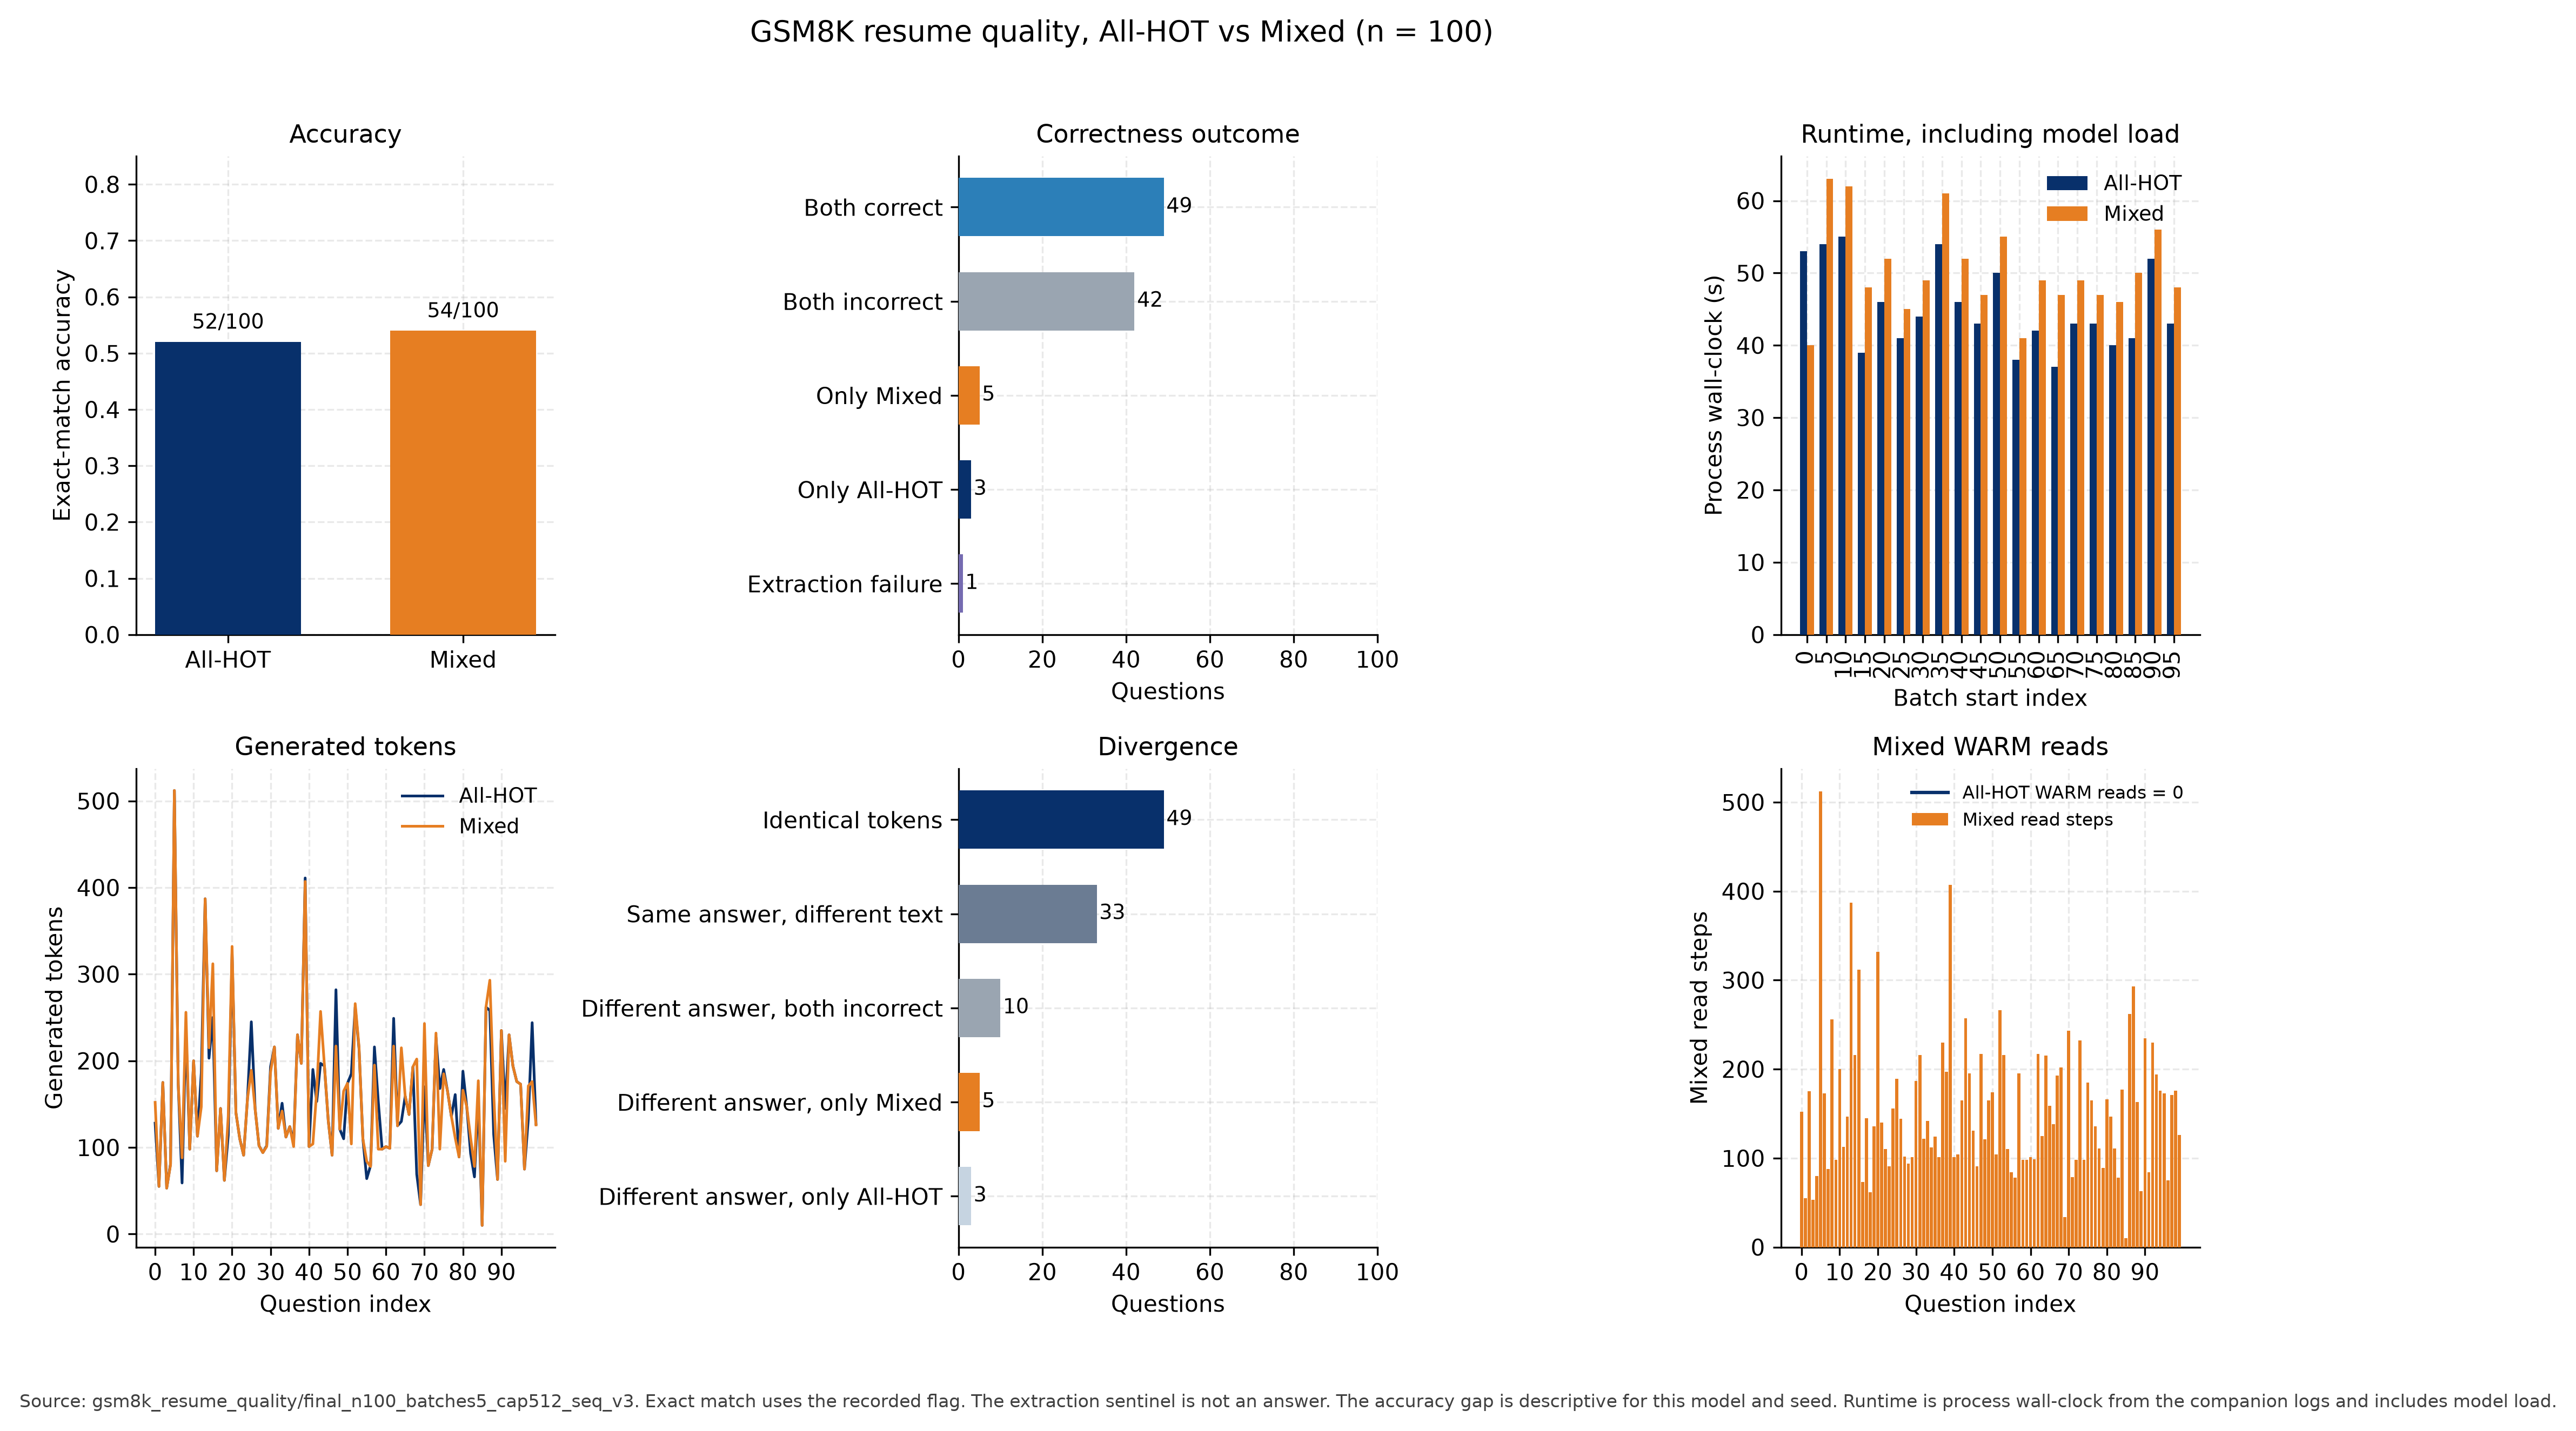

wrote experiments/hkv_pressure_study/plots/gsm8k_resume_quality.png
wrote experiments/hkv_pressure_study/plots/gsm8k_resume_quality.pdf


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13.6, 8.0))
n_both_correct = int((questions_view["correctness_category"] == "both_correct").sum())
n_both_incorrect = int((questions_view["correctness_category"] == "both_incorrect").sum())
n_only_hot = int((questions_view["correctness_category"] == "only_all_hot_correct").sum())
n_only_mix = int((questions_view["correctness_category"] == "only_mixed_correct").sum())
n_extraction = int(questions_view["correctness_category"].str.contains("extraction_failure").sum())

accuracy_ax = axes[0, 0]
acc_modes = ["all-hot", "mixed"]
acc_values = [hot_counts["exact_match"] / N_QUESTIONS, mix_counts["exact_match"] / N_QUESTIONS]
acc_counts = [hot_counts["exact_match"], mix_counts["exact_match"]]
accuracy_ax.bar(
    [MODE_LABELS[mode] for mode in acc_modes],
    acc_values,
    color=[MODE_COLORS[mode] for mode in acc_modes],
    width=0.62,
    zorder=3,
)
for x, value, count in zip((0, 1), acc_values, acc_counts):
    accuracy_ax.text(x, value + 0.015, f"{count}/{N_QUESTIONS}", ha="center", va="bottom", fontsize=9)
accuracy_ax.set_ylim(0, 0.85)
accuracy_ax.set_ylabel("Exact-match accuracy")
accuracy_ax.set_title("Accuracy")

outcome_ax = axes[0, 1]
outcome_labels = ["Both correct", "Both incorrect", "Only Mixed", "Only All-HOT", "Extraction failure"]
outcome_values = [n_both_correct, n_both_incorrect, n_only_mix, n_only_hot, n_extraction]
outcome_colors = ["#2c7fb8", "#9aa5b1", COLOR_MIXED, COLOR_ALL_HOT, "#756bb1"]
outcome_ax.barh(outcome_labels[::-1], outcome_values[::-1], color=outcome_colors[::-1], height=0.62, zorder=3)
for y, value in enumerate(outcome_values[::-1]):
    outcome_ax.text(value + 0.6, y, str(value), va="center", fontsize=9)
outcome_ax.set_xlim(0, N_QUESTIONS)
outcome_ax.set_xlabel("Questions")
outcome_ax.set_title("Correctness outcome")

runtime_ax = axes[0, 2]
batch_order = (
    files[["batch_number", "start_index"]]
    .drop_duplicates()
    .sort_values("start_index")
)
x = list(range(len(batch_order)))
width = 0.36
for offset, mode in ((-width / 2, "all-hot"), (width / 2, "mixed")):
    heights = []
    for start_index in batch_order["start_index"]:
        heights.append(
            float(
                files.loc[
                    (files["start_index"] == start_index) & (files["mode"] == mode),
                    "log_wall_seconds",
                ].iloc[0]
            )
        )
    runtime_ax.bar(
        [item + offset for item in x],
        heights,
        width=width,
        color=MODE_COLORS[mode],
        label=MODE_LABELS[mode],
        zorder=3,
    )
runtime_ax.set_xticks(x, [str(int(value)) for value in batch_order["start_index"]], rotation=90)
runtime_ax.set_xlabel("Batch start index")
runtime_ax.set_ylabel("Process wall-clock (s)")
runtime_ax.set_title("Runtime, including model load")
runtime_ax.legend()

token_ax = axes[1, 0]
token_ax.plot(
    questions_view["question_index"],
    questions_view["all_hot_generated_token_count"],
    color=COLOR_ALL_HOT,
    linewidth=1.2,
    label="All-HOT",
)
token_ax.plot(
    questions_view["question_index"],
    questions_view["mixed_generated_token_count"],
    color=COLOR_MIXED,
    linewidth=1.2,
    label="Mixed",
)
token_ax.set_xlabel("Question index")
token_ax.set_ylabel("Generated tokens")
token_ax.set_title("Generated tokens")
token_ax.set_xticks(range(0, N_QUESTIONS, 10))
token_ax.legend()

div_ax = axes[1, 1]
n_different_both_incorrect = int(
    (
        (questions_view["correctness_category"] == "both_incorrect")
        & ~questions_view["extracted_answers_identical"]
    ).sum()
)
div_labels = [
    "Identical tokens",
    "Same answer, different text",
    "Different answer, both incorrect",
    "Different answer, only Mixed",
    "Different answer, only All-HOT",
]
div_values = [
    n_identical_tokens,
    n_same_answer_different_text,
    n_different_both_incorrect,
    n_only_mix,
    n_only_hot,
]
div_colors = ["#08306b", "#6b7c93", "#9aa5b1", COLOR_MIXED, "#c6d4e1"]
div_ax.barh(div_labels[::-1], div_values[::-1], color=div_colors[::-1], height=0.62, zorder=3)
for y, value in enumerate(div_values[::-1]):
    div_ax.text(value + 0.6, y, str(value), va="center", fontsize=9)
div_ax.set_xlim(0, N_QUESTIONS)
div_ax.set_xlabel("Questions")
div_ax.set_title("Divergence")

mixed_reads = sessions.loc[sessions["mode"] == "mixed", ["question_index", "mixed_read_steps"]].sort_values(
    "question_index"
)
warm_ax = axes[1, 2]
warm_ax.bar(
    mixed_reads["question_index"],
    mixed_reads["mixed_read_steps"],
    color=COLOR_MIXED,
    width=0.8,
    zorder=3,
    label="Mixed read steps",
)
warm_ax.plot([], [], color=COLOR_ALL_HOT, linewidth=1.5, label="All-HOT WARM reads = 0")
warm_ax.set_xlabel("Question index")
warm_ax.set_ylabel("Mixed read steps")
warm_ax.set_title("Mixed WARM reads")
warm_ax.set_xticks(range(0, N_QUESTIONS, 10))
warm_ax.legend(fontsize=8)

fig.suptitle("GSM8K resume quality, All-HOT vs Mixed (n = 100)", fontsize=13, y=1.02)
fig.text(
    0.0,
    -0.04,
    "Source: gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3. "
    "Exact match uses the recorded flag. The extraction sentinel is not an answer. "
    "The accuracy gap is descriptive for this model and seed. "
    "Runtime is process wall-clock from the companion logs and includes model load.",
    ha="left",
    va="top",
    fontsize=8,
    color="0.25",
)
fig.tight_layout()
plot_paths = []
for suffix in ("png", "pdf"):
    path = PLOTS / f"gsm8k_resume_quality.{suffix}"
    fig.savefig(path)
    plot_paths.append(path)
plt.close(fig)
display(Image(filename=str(plot_paths[0])))
for path in plot_paths:
    print("wrote", rel(path))


## 7. Evidence that Mixed used the physical WARM INT8 path

`warm_dtype` is the configured WARM element type. `warm_residency` is the
pre-resume list of logical blocks placed in WARM slots. `mixed_read_steps`
counts generation steps that read those slots. `peak_warm_blocks` is the
observed WARM-resident peak, including ballast beyond the five evaluated
questions. The JSON has no HOT-reclaim counter, so the pre-resume snapshot is
checked directly for null-backed block ids.


In [7]:
mixed_files = files[files["mode"] == "mixed"].copy()
mixed_sessions = sessions[sessions["mode"] == "mixed"].copy()
hkv_questions = mixed_sessions[
    [
        "batch",
        "batch_number",
        "question_index",
        "session_id",
        "complete_historical_blocks",
        "warm_residency_blocks",
        "warm_logical_blocks_observed",
        "mixed_read_steps",
        "generated_token_count",
        "pre_resume_warm_confirmed",
        "attention_had_warm_slots",
        "warm_logical_block_ids_zero",
        "temporary_shadow_hot_ids_set",
        "eligible",
    ]
].copy()
hkv_questions["residency_covers_complete_blocks"] = (
    hkv_questions["warm_residency_blocks"] == hkv_questions["complete_historical_blocks"]
)
hkv_questions["reads_cover_generation"] = (
    hkv_questions["mixed_read_steps"] == hkv_questions["generated_token_count"]
)

batch_hkv = mixed_files[
    [
        "batch",
        "batch_number",
        "start_index",
        "warm_dtype",
        "warm_dtype_bytes",
        "warm_observed",
        "peak_warm_blocks",
        "peak_warm_requests",
        "peak_owned_warm_slots",
        "warm_kv_storage_bytes",
        "hot_to_warm_map_storage_bytes",
        "final_warm_blocks",
        "cleanup_complete",
        "allocator_consistent",
        "num_ballast_sessions_planned",
        "log_hot_to_warm_transitions",
        "log_hot_to_warm_changed_blocks",
    ]
].copy()
residency_by_batch = mixed_sessions.groupby("batch")["warm_residency_blocks"].sum()
batch_hkv["evaluated_warm_residency_blocks"] = batch_hkv["batch"].map(residency_by_batch)
batch_hkv["warm_blocks_beyond_evaluated_questions"] = (
    batch_hkv["peak_warm_blocks"] - batch_hkv["evaluated_warm_residency_blocks"]
)

assert set(mixed_files["warm_dtype"]) == {"int8"}
assert (mixed_files["warm_dtype_bytes"] == 1).all()
assert mixed_files["warm_observed"].all()
assert (mixed_files["warm_kv_storage_bytes"] > 0).all()
assert (mixed_files["hot_to_warm_map_storage_bytes"] > 0).all()
assert (mixed_files["final_warm_blocks"] == 0).all()
assert mixed_files["cleanup_complete"].all()
assert mixed_files["allocator_consistent"].all()
assert hkv_questions["pre_resume_warm_confirmed"].all()
assert hkv_questions["attention_had_warm_slots"].all()
assert hkv_questions["eligible"].all()
assert hkv_questions["residency_covers_complete_blocks"].all()
assert (hkv_questions["mixed_read_steps"] > 0).all()
assert (hkv_questions["warm_logical_blocks_observed"] == hkv_questions["complete_historical_blocks"]).all()
assert int(hkv_questions["warm_logical_block_ids_zero"].sum()) == 0
assert (hkv_questions["temporary_shadow_hot_ids_set"] == hkv_questions["warm_residency_blocks"]).all()
assert (files.loc[files["mode"] == "all-hot", "warm_observed"] == False).all()
assert (files.loc[files["mode"] == "all-hot", "warm_kv_storage_bytes"] == 0).all()
assert (files.loc[files["mode"] == "all-hot", "log_hot_to_warm_transitions"] == 0).all()
assert (mixed_files["log_hot_to_warm_changed_blocks"] == mixed_files["peak_warm_blocks"]).all()

read_gaps = hkv_questions.loc[
    ~hkv_questions["reads_cover_generation"],
    ["batch", "question_index", "session_id", "mixed_read_steps", "generated_token_count"],
]
print("Mixed batch HKV records")
display(batch_hkv.drop(columns=["warm_kv_storage_bytes", "hot_to_warm_map_storage_bytes"]))
print(
    "evaluated questions with WARM residency:",
    int(hkv_questions["residency_covers_complete_blocks"].sum()),
    "/",
    len(hkv_questions),
)
print("HOT-to-WARM residency entries on evaluated questions:", int(hkv_questions["warm_residency_blocks"].sum()))
print("WARM read steps on evaluated questions:", int(hkv_questions["mixed_read_steps"].sum()))
print(
    "pre-resume logical blocks with block_id 0:",
    int(hkv_questions["warm_logical_block_ids_zero"].sum()),
)
print(
    "residency entries that still carry temporary_shadow_hot_block_id:",
    int(hkv_questions["temporary_shadow_hot_ids_set"].sum()),
    "/",
    int(hkv_questions["warm_residency_blocks"].sum()),
)
print(
    "peak WARM blocks:",
    int(mixed_files["peak_warm_blocks"].min()),
    "to",
    int(mixed_files["peak_warm_blocks"].max()),
)
print("questions where mixed_read_steps differs from generated token count:")
display(read_gaps)
print("All-HOT warm_observed is false, warm_kv_storage_bytes is 0, and the logs contain no hot->warm line.")


Mixed batch HKV records


,batch,batch_number,start_index,warm_dtype,warm_dtype_bytes,warm_observed,peak_warm_blocks,peak_warm_requests,peak_owned_warm_slots,final_warm_blocks,cleanup_complete,allocator_consistent,num_ballast_sessions_planned,log_hot_to_warm_transitions,log_hot_to_warm_changed_blocks,evaluated_warm_residency_blocks,warm_blocks_beyond_evaluated_questions
1,batch_01_start_000,1,0,int8,1,True,357,6,357,0,True,True,8,6,357,232,125
3,batch_02_start_005,2,5,int8,1,True,358,6,358,0,True,True,8,6,358,234,124
5,batch_03_start_010,3,10,int8,1,True,358,6,358,0,True,True,8,6,358,233,125
7,batch_04_start_015,4,15,int8,1,True,358,6,358,0,True,True,8,6,358,233,125
9,batch_05_start_020,5,20,int8,1,True,354,6,354,0,True,True,8,6,354,229,125
11,batch_06_start_025,6,25,int8,1,True,358,6,358,0,True,True,8,6,358,233,125
13,batch_07_start_030,7,30,int8,1,True,352,6,352,0,True,True,8,6,352,227,125
15,batch_08_start_035,8,35,int8,1,True,357,6,357,0,True,True,8,6,357,232,125
17,batch_09_start_040,9,40,int8,1,True,364,6,364,0,True,True,8,6,364,240,124
19,batch_10_start_045,10,45,int8,1,True,359,6,359,0,True,True,8,6,359,235,124


evaluated questions with WARM residency: 100 / 100
HOT-to-WARM residency entries on evaluated questions: 4654
WARM read steps on evaluated questions: 15729
pre-resume logical blocks with block_id 0: 0
residency entries that still carry temporary_shadow_hot_block_id: 4654 / 4654
peak WARM blocks: 352 to 364
questions where mixed_read_steps differs from generated token count:


,batch,question_index,session_id,mixed_read_steps,generated_token_count
29,batch_03_start_010,14,gsm8k-0014,216,215


All-HOT warm_observed is false, warm_kv_storage_bytes is 0, and the logs contain no hot->warm line.


## 8. Earlier runs excluded from this aggregate

`final_n100_batches5_cap512_seq_v3` is the only directory scored above. The
cells below read failure markers and list every GSM8K resume-quality directory
so partial, smoke, and earlier runs stay out of the totals.


In [8]:
def failure_hint(log_text: str) -> str:
    if "ModuleNotFoundError: No module named 'experiments'" in log_text:
        return "import failed before generation"
    if "EngineCore failed to start" in log_text:
        return "vLLM engine failed to start"
    if not log_text.strip():
        return "log is empty"
    return "see the log for the recorded error"


print("final directory FAILED.txt:", "present" if (FINAL_DIR / "FAILED.txt").exists() else "absent")
for failed_dir in FAILED_ATTEMPTS:
    print("---")
    print("excluded:", rel(failed_dir))
    marker = failed_dir / "FAILED.txt"
    print("FAILED.txt:", marker.read_text(encoding="utf-8").strip() if marker.is_file() else "absent")
    json_paths = sorted(failed_dir.rglob("*.json"))
    log_paths = sorted(failed_dir.rglob("*.log"))
    print("json files:", len(json_paths))
    print("log files:", ", ".join(rel(path) for path in log_paths) or "none")
    if log_paths:
        text = log_paths[0].read_text(encoding="utf-8", errors="replace")
        print("classification:", failure_hint(text))
    assert not json_paths, [rel(path) for path in json_paths]

rows = []
for path in sorted(RUNS.iterdir()):
    if not path.is_dir():
        continue
    json_count = len(list(path.rglob("*.json")))
    if path.resolve() == FINAL_DIR.resolve():
        role = "final 100-question aggregate"
    elif path.resolve() in {item.resolve() for item in FAILED_ATTEMPTS}:
        role = "failed attempt; keep the marker and log, exclude from statistics"
    elif path.resolve() == PRIOR_N20_DIR.resolve():
        role = "earlier 20-question cap-512 run; exclude from this aggregate"
    elif path.name.startswith("smoke") or "debug" in path.name or "retry" in path.name:
        role = "smoke, debug, or retry; do not present as final"
    elif path.name.startswith("preflight"):
        role = "preflight; do not present as final"
    elif "sync" in path.name:
        role = "synchronous-scheduling trial; do not present as final"
    else:
        role = "earlier or partial run; do not present as final"
    rows.append({"directory": path.name, "json_files": json_count, "role": role})
inventory = pd.DataFrame(rows)
display(inventory)
print("preserve the final result JSON:")
for record in records:
    for filename in ("all_hot.json", "mixed.json"):
        print(" ", rel(record["batch_dir"] / filename))


final directory FAILED.txt: absent
---
excluded: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq
FAILED.txt: FAILED batch 1 All-HOT at Mon Sep 21 11:09:00 PM IDT 2026
json files: 0
log files: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq/batch_01_start_000/all_hot.log
classification: import failed before generation
---
excluded: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v2
FAILED.txt: FAILED batch 1 All-HOT at Tue Sep 22 07:52:04 PM IDT 2026
json files: 0
log files: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v2/batch_01_start_000/all_hot.log
classification: vLLM engine failed to start


,directory,json_files,role
0,final_n100_batches5_cap512_seq,0,"failed attempt; keep the marker and log, exclude from statistics"
1,final_n100_batches5_cap512_seq_v2,0,"failed attempt; keep the marker and log, exclude from statistics"
2,final_n100_batches5_cap512_seq_v3,40,final 100-question aggregate
3,final_n20_batches5,8,earlier or partial run; do not present as final
4,final_n20_batches5_cap512_seq,8,earlier 20-question cap-512 run; exclude from this aggregate
5,final_q5_cap512_seq_rep1,1,earlier or partial run; do not present as final
6,final_q5_cap512_seq_v2_rep1,2,earlier or partial run; do not present as final
7,final_q5_cap512_sync_rep1,3,synchronous-scheduling trial; do not present as final
8,preflight,2,preflight; do not present as final
9,preflight_scale,6,preflight; do not present as final


preserve the final result JSON:
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/batch_01_start_000/all_hot.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/batch_01_start_000/mixed.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/batch_02_start_005/all_hot.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/batch_02_start_005/mixed.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/batch_03_start_010/all_hot.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/batch_03_start_010/mixed.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/batch_04_start_015/all_hot.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3/batch_

## 9. Save the final tables

The study CSVs are rewritten from this 100-question aggregate. If a previous
summary is still the 20-question table, it is reported and then replaced.


In [9]:
SUMMARY_PATH = TABLES / "gsm8k_quality_summary.csv"
PER_QUESTION_PATH = TABLES / "gsm8k_per_question.csv"
DIVERGENT_PATH = TABLES / "gsm8k_divergent_answers.csv"

if SUMMARY_PATH.is_file():
    previous = pd.read_csv(SUMMARY_PATH)
    if {"metric", "value"}.issubset(previous.columns):
        previous_n = previous.loc[previous["metric"] == "n_questions", "value"]
        if len(previous_n):
            print(
                f"previous {rel(SUMMARY_PATH)} recorded n_questions={previous_n.iloc[0]} "
                "from the 20-question run; replacing it with the 100-question final tables"
            )
    else:
        print(f"replacing existing {rel(SUMMARY_PATH)}")

summary_out = quality_summary.reset_index().rename(columns={"All-HOT": "all_hot", "Mixed": "mixed"})
summary_out.insert(0, "table", "quality")
performance_out = performance.reset_index().rename(columns={"All-HOT": "all_hot", "Mixed": "mixed"})
performance_out.insert(0, "table", "performance")
pairing_out = divergence_summary.rename(columns={"comparison": "metric", "questions": "paired"})
pairing_out.insert(0, "table", "pairing")
pairing_out["all_hot"] = pd.NA
pairing_out["mixed"] = pd.NA
saved_summary = pd.concat(
    [
        summary_out,
        performance_out,
        pairing_out[["table", "metric", "all_hot", "mixed", "paired"]],
    ],
    ignore_index=True,
)
saved_summary.to_csv(SUMMARY_PATH, index=False)

per_question_out = questions_view.copy()
per_question_out.to_csv(PER_QUESTION_PATH, index=False)

divergent = answer_splits.merge(question_text, on="question_index", how="left")
divergent = divergent.sort_values("question_index").reset_index(drop=True)
divergent.to_csv(DIVERGENT_PATH, index=False)

print("wrote", rel(SUMMARY_PATH))
print("wrote", rel(PER_QUESTION_PATH), f"({len(per_question_out)} rows)")
print("wrote", rel(DIVERGENT_PATH), f"({len(divergent)} rows)")


replacing existing experiments/hkv_pressure_study/tables/gsm8k_quality_summary.csv
wrote experiments/hkv_pressure_study/tables/gsm8k_quality_summary.csv
wrote experiments/hkv_pressure_study/tables/gsm8k_per_question.csv (100 rows)
wrote experiments/hkv_pressure_study/tables/gsm8k_divergent_answers.csv (19 rows)


## Key findings


In [10]:
only_hot = questions_view.loc[
    questions_view["correctness_category"] == "only_all_hot_correct", "question_index"
].tolist()
only_mix = questions_view.loc[
    questions_view["correctness_category"] == "only_mixed_correct", "question_index"
].tolist()
extraction_rows = questions_view.loc[
    questions_view["correctness_category"].str.contains("extraction_failure"),
    ["question_index", "question_id", "all_hot_generated_token_count", "mixed_generated_token_count"],
]
read_gap_text = "Mixed read steps equal generated tokens on every evaluated question."
if len(read_gaps):
    bits = [
        (
            f"question {int(row.question_index)} ({row.session_id}) has "
            f"{int(row.mixed_read_steps)} Mixed read steps and {int(row.generated_token_count)} generated tokens"
        )
        for row in read_gaps.itertuples(index=False)
    ]
    noun = "question" if len(read_gaps) == 1 else "questions"
    read_gap_text = (
        f"{len(read_gaps)} Mixed {noun} where read steps differ from generated tokens: "
        + "; ".join(bits)
        + "."
    )

extraction_text = "No question failed answer extraction."
if len(extraction_rows):
    extraction_text = "; ".join(
        (
            f"question {int(row.question_index)} ({row.question_id}) generated "
            f"{int(row.all_hot_generated_token_count)} All-HOT tokens and "
            f"{int(row.mixed_generated_token_count)} Mixed tokens"
        )
        for row in extraction_rows.itertuples(index=False)
    )

hot_perf = performance["All-HOT"]
mix_perf = performance["Mixed"]
findings = f"""
The final dataset is `{rel(FINAL_DIR)}`: 20 batches, question indices 0–99, and no `FAILED.txt`.

All {N_QUESTIONS} questions completed two turns in both modes. Failed questions: {hot_counts['failed']} All-HOT and {mix_counts['failed']} Mixed. Timed-out questions, counted only from error text: {hot_counts['timed_out']} and {mix_counts['timed_out']}.

Answer extraction succeeded on {hot_counts['extraction_success']}/{N_QUESTIONS} All-HOT questions and {mix_counts['extraction_success']}/{N_QUESTIONS} Mixed questions. Extraction failures: {extraction_text}. The harness sentinel `-9999999` is omitted from the extracted-answer columns.

Exact match is {hot_counts['exact_match']}/{N_QUESTIONS} ({hot_counts['exact_match'] / N_QUESTIONS:.2f}) for All-HOT and {mix_counts['exact_match']}/{N_QUESTIONS} ({mix_counts['exact_match'] / N_QUESTIONS:.2f}) for Mixed. Incorrect extracted answers, after removing extraction failures, are {hot_counts['incorrect_extracted_answers']} and {mix_counts['incorrect_extracted_answers']}.

Paired outcomes: {n_both_correct} both correct, {n_both_incorrect} both incorrect, {n_only_hot} only All-HOT ({only_hot}), {n_only_mix} only Mixed ({only_mix}). Token sequences match on {n_identical_tokens} questions. Real extracted answers match on {n_identical_answers} questions and differ on {n_different_answers}. {n_same_answer_different_text} questions share an extracted answer with different token sequences.

All-HOT generated {int(hot_perf['generated_tokens'])} tokens ({hot_perf['avg_generated_tokens']:.2f} per question). Mixed generated {int(mix_perf['generated_tokens'])} tokens ({mix_perf['avg_generated_tokens']:.2f} per question). Log wall-clock, including model load, is {hot_perf['log_wall_seconds']:.0f}s for All-HOT and {mix_perf['log_wall_seconds']:.0f}s for Mixed. Peak GPU allocation is {hot_perf['peak_gpu_allocated_GiB']:.3f} GiB and peak GPU reserved is {hot_perf['peak_gpu_reserved_GiB']:.3f} GiB for All-HOT, against {mix_perf['peak_gpu_allocated_GiB']:.3f} GiB allocated and {mix_perf['peak_gpu_reserved_GiB']:.3f} GiB reserved for Mixed. Mixed reserves {mix_perf['warm_kv_storage_GiB']:.3f} GiB of INT8 WARM storage; All-HOT records 0.

Every Mixed question was WARM-resident before resume, `warm_dtype` is int8, and the companion-log `hot->warm` block totals equal `peak_warm_blocks` ({int(mixed_files['peak_warm_blocks'].min())}–{int(mixed_files['peak_warm_blocks'].max())}). {read_gap_text} The pre-resume snapshot still has non-zero block ids and temporary shadow HOT ids, so it does not record a HOT reclaim. `final_warm_blocks=0` with `cleanup_complete=true` is cleanup after the run.

The exact-match gap on this sample is {mix_counts['exact_match'] - hot_counts['exact_match']} question in favor of Mixed, with {n_only_hot} questions correct only under All-HOT and {n_only_mix} only under Mixed. The run uses one model (`{files['model'].iloc[0]}`) and one seed (`{int(files['seed'].iloc[0])}`). That gap describes this sample.
"""
# The last sentence above is awkward if the gap is not 1. Fix grammatically below.
gap = mix_counts["exact_match"] - hot_counts["exact_match"]
if gap == 0:
    gap_sentence = "Exact match is the same for All-HOT and Mixed on this sample."
elif gap > 0:
    gap_sentence = (
        f"Mixed has {gap} more exact matches than All-HOT on this sample, "
        f"with {n_only_hot} questions correct only under All-HOT and {n_only_mix} only under Mixed."
    )
else:
    gap_sentence = (
        f"All-HOT has {-gap} more exact matches than Mixed on this sample, "
        f"with {n_only_hot} questions correct only under All-HOT and {n_only_mix} only under Mixed."
    )
findings = findings.replace(
    f"The exact-match gap on this sample is {gap} question in favor of Mixed, with {n_only_hot} questions correct only under All-HOT and {n_only_mix} only under Mixed. The run uses one model (`{files['model'].iloc[0]}`) and one seed (`{int(files['seed'].iloc[0])}`). That gap describes this sample.",
    gap_sentence
    + f" The run uses one model (`{files['model'].iloc[0]}`) and one seed (`{int(files['seed'].iloc[0])}`). "
    + "The comparison describes this sample.",
)
display(Markdown(findings))



The final dataset is `experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq_v3`: 20 batches, question indices 0–99, and no `FAILED.txt`.

All 100 questions completed two turns in both modes. Failed questions: 0 All-HOT and 0 Mixed. Timed-out questions, counted only from error text: 0 and 0.

Answer extraction succeeded on 99/100 All-HOT questions and 99/100 Mixed questions. Extraction failures: question 5 (gsm8k-0005) generated 512 All-HOT tokens and 512 Mixed tokens. The harness sentinel `-9999999` is omitted from the extracted-answer columns.

Exact match is 52/100 (0.52) for All-HOT and 54/100 (0.54) for Mixed. Incorrect extracted answers, after removing extraction failures, are 47 and 45.

Paired outcomes: 49 both correct, 42 both incorrect, 3 only All-HOT ([51, 70, 80]), 5 only Mixed ([15, 57, 68, 88, 97]). Token sequences match on 49 questions. Real extracted answers match on 81 questions and differ on 18. 33 questions share an extracted answer with different token sequences.

All-HOT generated 15669 tokens (156.69 per question). Mixed generated 15728 tokens (157.28 per question). Log wall-clock, including model load, is 904s for All-HOT and 1007s for Mixed. Peak GPU allocation is 4.862 GiB and peak GPU reserved is 5.006 GiB for All-HOT, against 4.885 GiB allocated and 5.072 GiB reserved for Mixed. Mixed reserves 0.902 GiB of INT8 WARM storage; All-HOT records 0.

Every Mixed question was WARM-resident before resume, `warm_dtype` is int8, and the companion-log `hot->warm` block totals equal `peak_warm_blocks` (352–364). 1 Mixed question where read steps differ from generated tokens: question 14 (gsm8k-0014) has 216 Mixed read steps and 215 generated tokens. The pre-resume snapshot still has non-zero block ids and temporary shadow HOT ids, so it does not record a HOT reclaim. `final_warm_blocks=0` with `cleanup_complete=true` is cleanup after the run.

Mixed has 2 more exact matches than All-HOT on this sample, with 3 questions correct only under All-HOT and 5 only under Mixed. The run uses one model (`Qwen/Qwen3-0.6B`) and one seed (`0`). The comparison describes this sample.
